# **1. Présentation Générale**

Il est question ici d'appliquer et d'analyser deux algorithmes de classification spécifiques, chacun adressant un jeu de données et une problématique distincte :

* D'une part, de classifier les individus selon leur niveau de revenu ($\le50\text{K}$ ou $>50\text{K}$) en utilisant l'algorithme des **K plus proches voisins (KNN)**, appliqué au Jeu de données Adult.
* D'autre part, d'évaluer la capacité du **Gradient Boosting (GBM)** à classifier les publications scientifiques sur les bases Cora en exploitant les informations des caractéristiques et du réseau de citations.


## **1.1 Problématique**

La problématique est donc la suivante :

> **Comment évaluer, comparer et optimiser les algorithmes de KNN et de Gradient Boosting pour résoudre les défis spécifiques posés par le jeu de données Adult et les données relationnelles?**

Répondre à cette problématique nous amènera à :

* **Réaliser une Analyse Exploratoire des Données**, incluant le nettoyage, l'encodage des variables catégorielles et l'analyse du déséquilibre de classe (crucial pour le KNN sur Adult).
* **Préparer et transformer les données** pour les modèles, notamment par la normalisation des variables (spécifique au KNN) et la création de la matrice combinée $M=D^{\wedge}(-1)^{*}W^{*}X$ (spécifique au Gradient Boosting sur données relationnelles).
* **Appliquer les méthodes de classification supervisée** (KNN et Gradient Boosting) et procéder à l'optimisation des hyperparamètres spécifiques à chaque modèle.
* **Évaluer et comparer les modèles** à l'aide de métriques pertinentes (accuracy, F-mesure, précision, rappel, ou courbe ROC).

In [ ]:
! pip install ucimlrepo

# Importation des librairies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from imblearn.combine import SMOTEENN
from collections import Counter
from sklearn.model_selection import train_test_split

# **2. Présentation des Données**

Les données utilisées pour réaliser cette analyse ont été obtenues de deux sources distinctes :

* **Jeu de données Adult (Classification Binaire de Revenu)** :
    * Ce jeu de données a été obtenu sur l'archive UCI à l'adresse **[https://archive.ics.uci.edu/dataset/2/adult](https://archive.ics.uci.edu/dataset/2/adult)**.
    * Il comprend 48 842 exemples et 14 attributs.
    * La variable cible est binaire : **=< 50 K ou >50 K**.

* **Données Relationnelles (Classification de Publications Scientifiques)** :
    * La base **Cora** est utilisée pour l'étude de la classification relationnelle.
    * Elle fournit une matrice de caractéristiques **(X)** et une matrice d'adjacence **(W)** des liens entre les individus.
    * Les caractéristiques clés sont résumées comme suit:
        * **Cora** : 2780 individus, 5429 liens, 1433 variables, 7 classes.

# **Partie 1 : KNN sur le jeu de données adult**

## **I - Récupération des données**

In [ ]:
# fetch dataset
adult = fetch_ucirepo(id=2)


In [ ]:
# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

In [ ]:
# metadata
print(adult.metadata)

{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [ ]:
# variable information
adult.variables

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,N/A,None,no
1,workclass,Feature,Categorical,Income,"Private, Self-emp-not-inc, Self-emp-inc, Feder...",None,yes
2,fnlwgt,Feature,Integer,None,None,None,no
3,education,Feature,Categorical,Education Level,"Bachelors, Some-college, 11th, HS-grad, Prof-...",None,no
4,education-num,Feature,Integer,Education Level,None,None,no
5,marital-status,Feature,Categorical,Other,"Married-civ-spouse, Divorced, Never-married, S...",None,no
6,occupation,Feature,Categorical,Other,"Tech-support, Craft-repair, Other-service, Sal...",None,yes
7,relationship,Feature,Categorical,Other,"Wife, Own-child, Husband, Not-in-family, Other...",None,no
8,race,Feature,Categorical,Race,"White, Asian-Pac-Islander, Amer-Indian-Eskimo,...",None,no
9,sex,Feature,Binary,Sex,"Female, Male.",None,no


In [ ]:
X.shape

(48842, 14)

In [ ]:
y.shape

(48842, 1)

## **II - Analyse Exploratoire et Identification des Problèmes**

Ici il est question de réaliser une analyse exploratoire pour comprendre la structure des données et identifier les problèmes qui nécessiteront un prétraitement.

### **Inspection des Données et Types de Variables**

Ici, on vérifie les premières lignes des données et les types de variables pour identifier clairement les attributs numériques et catégoriels.

* **Action 1 : Afficher les premières lignes de X et y.** (Pour visualiser l'aspect des données brutes).
* **Action 2 : Vérifier les types de données de chaque colonne dans X** (Pour s'assurer que Pandas a correctement interprété les types).


In [ ]:
print("--- Premières lignes des caractéristiques (X) ---")
X.head(2)

--- Premières lignes des caractéristiques (X) ---


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States


In [ ]:
print("\n--- Premières lignes de la variable cible (y) ---")
y.head(2)


--- Premières lignes de la variable cible (y) ---


,income
0,<=50K
1,<=50K


In [ ]:
print("\n--- Types de données des colonnes de X ---")
X.info()


--- Types de données des colonnes de X ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
dtypes: int64(6), object(8)
memory usage: 5.2+ MB


In [ ]:
print("\n--- Types de données des colonnes de y ---")
y.info()


--- Types de données des colonnes de y ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   income  48842 non-null  object
dtypes: object(1)
memory usage: 381.7+ KB


**Observations** :

- L'inspection des données révèle que le jeu de données Adult se compose de $48\ 842$ observations avec $14$ caractéristiques : dont **6 sont numériques** (`age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`) et **8 sont catégorielles** (`workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `sex`, `native-country`).
- La variable cible, **`income`**, est catégorielle et doit être encodée.
- De plus, bien que Pandas ait initialement détecté des valeurs manquantes (`NaN`) dans trois colonnes catégorielles (`workclass`, `occupation`, et `native-country`), il est nécessaire de vérifier en profondeur la présence d'autres codages de valeurs manquantes, notamment le caractère **`?`**, `'NaN'`, `'Not in universe'`, `'Not identifiable'`, `'Do not know'`, et `'N/A'`, qui est une pratique courante dans ce type de base de données.



In [ ]:
def detect_suspect_values(df):
    """
    Détecte les valeurs textuelles potentiellement non informatives dans chaque colonne du DataFrame.

    Cible les chaînes contenant : 'NA', 'Not', '?'.
    """
    print("Détection des valeurs suspectes :\n")
    for col in df.columns:
        uniques = df[col].unique()
        filtered = [val for val in uniques if isinstance(val, str) and ("NA" in val or "Not" in val or "?" in val or "N/A" in val)]
        if filtered:
            print(f"Colonne '{col}' :")
            print(filtered)
            print()


In [ ]:
detect_suspect_values(X)

Détection des valeurs suspectes :

Colonne 'workclass' :
['?']

Colonne 'occupation' :
['?']

Colonne 'relationship' :
['Not-in-family']

Colonne 'native-country' :
['?']



**Validation de l'étape : Détection des Valeurs Suspectes**

- Les résultats confirment que les colonnes `workclass`, `occupation`, et `native-country` contiennent effectivement le caractère **`?`** comme valeur manquante, en plus des `NaN` initiaux détectés.

- L'élément `Not-in-family` dans la colonne `relationship` n'est pas une valeur manquante, mais une catégorie valide (même si elle contient "Not", elle décrit bien une relation). Il sera traité lors de l'encodage des variables catégorielles.


### **Gestion des Valeurs Manquantes**

Pour tout jeu de données réel, il est crucial d'identifier l'étendue et la nature des valeurs manquantes et de voir comment les traiter.
    


In [ ]:
# liste de valeurs à traiter comme manquantes
missing_like_values = [
    '?',
    ' ?',
    'NA',
    ' NA',
    'N/A',
    ' N/A',
    'NaN',
    ' NaN'
]



In [ ]:
def count_na_values(df, missing_like_values):
    """
    Remplace les chaînes non informatives par 'NA', puis compte les occurrences par colonne.

    Retourne :
    - Un DataFrame avec :
        - Colonne : nom de la variable
        - Total NA : nombre de 'NA'
        - Pourcentage NA (%) : proportion de 'NA' par rapport au nombre total de lignes
    """
    # Remplacement dans le DataFrame
    df = df.replace(to_replace=missing_like_values, value='NA')

    # Comptage des 'NA'
    total_rows = len(df)
    summary = []

    for col in df.columns:
        count = df[col].apply(lambda x: isinstance(x, str) and x.strip() == 'NA').sum()
        if count > 0:
            percentage = (count / total_rows) * 100
            summary.append({
                'Colonne': col,
                'Total NA': count,
                'Pourcentage NA (%)': round(percentage, 2)
            })

    return df, pd.DataFrame(summary).sort_values(by='Total NA', ascending=False)

In [ ]:
X, na_summary = count_na_values(X, missing_like_values)
print("Distribution des valeurs manquantes par colonnes \n")
print(f"On a {na_summary.shape[0]} colonnes qui ont des valeurs manquantes")
na_summary

Distribution des valeurs manquantes par colonnes 

On a 3 colonnes qui ont des valeurs manquantes


,Colonne,Total NA,Pourcentage NA (%)
1,occupation,1843,3.77
0,workclass,1836,3.76
2,native-country,583,1.19


**Décision** :

Les résultats de la quantification confirment que seulement trois colonnes catégorielles contiennent des valeurs manquantes : `occupation` ($3.77\%$), `workclass` ($3.76\%$), et `native-country` ($1.19\%$). Étant donné que le nombre total d'observations est très important ($48\ 842$) et que le pourcentage de valeurs manquantes dans les colonnes concernées est **relativement faible** (le maximum étant de $3.77\%$), la décision est de **supprimer les lignes (ou individus) contenant ces valeurs manquantes**.

In [ ]:
df_combined = pd.concat([X, y['income']], axis=1)

original_count = len(df_combined)
print(f"Taille dans le DF combiné AVANT suppression : {df_combined.shape}")

Taille dans le DF combiné AVANT suppression : (48842, 15)


In [ ]:
rows_to_drop_total = 0

print("\n--- Impact par Colonne sur la Suppression Globale ---")
for col in ['workclass', 'occupation', 'native-country']:

    # 1. Identifions les lignes contenant 'NA' dans la colonne actuelle
    count_na_in_col = (df_combined[col] == 'NA').sum()

    # 2. Affichage
    print(f"  - Colonne '{col}': {count_na_in_col} lignes contenaient 'NA'.")

# 3. Suppression Globale (en une seule fois, pour éviter la double suppression)
# Nous identifions les lignes À SUPPRIMER (lignes où l'une des 3 colonnes est 'NA')
rows_to_drop_mask = (df_combined['workclass'] == 'NA') | \
                    (df_combined['occupation'] == 'NA') | \
                    (df_combined['native-country'] == 'NA')

# Filtrons pour obtenir le DataFrame nettoyé (lignes SANS 'NA')
df_cleaned = df_combined[~rows_to_drop_mask]

# 4. Bilan Final
cleaned_count = len(df_cleaned)
rows_dropped = original_count - cleaned_count

# Séparation des DataFrames nettoyés
X_cleaned = df_cleaned.drop(columns=['income'])
y_cleaned = df_cleaned[['income']]

print("\n--- Bilan de la Suppression Globale ---")
print(f"Nombre de lignes APRÈS suppression : {cleaned_count}")
print(f"Nombre total de lignes supprimées (uniques) : {rows_dropped}")


--- Impact par Colonne sur la Suppression Globale ---
  - Colonne 'workclass': 1836 lignes contenaient 'NA'.
  - Colonne 'occupation': 1843 lignes contenaient 'NA'.
  - Colonne 'native-country': 583 lignes contenaient 'NA'.

--- Bilan de la Suppression Globale ---
Nombre de lignes APRÈS suppression : 46443
Nombre total de lignes supprimées (uniques) : 2399


## **III - Analyse du Déséquilibre de la Variable Cible**

Le problème de prédiction du revenu sur le jeu de données Adult est un cas de **classification déséquilibrée**. Il est impératif de quantifier ce déséquilibre.

* **Action : Calculer la distribution des classes dans `y`.**
    * Vérifier les proportions de la classe majoritaire et de la classe minoritaire.

### **III - 1 Encodage de la Variable Cible ($y_{\text{cleaned}}$)**

Puisque la variable cible `income` est catégorielle, elle doit être transformée en valeurs numériques (0 et 1) pour la modélisation.

  * La valeur **1** correspondra au revenu **$>50\text{K}$**.
  * La valeur **0** correspondra au revenu **$\le50\text{K}$**.

In [ ]:
# 1. Encodage : 1 pour '>50K', 0 pour '<=50K'
# Nous nous assurons de nettoyer les espaces au cas où
y_encoded_final = y_cleaned['income'].astype(str).str.strip().apply(lambda x: 1 if x == '>50K' else 0)

# 2. Quantification du Déséquilibre
print("--- Distribution de la Variable Cible Encoded (y_encoded_final) ---")
print(y_encoded_final.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


--- Distribution de la Variable Cible Encoded (y_encoded_final) ---
income
0    83.83%
1    16.17%
Name: proportion, dtype: object


/tmp/ipython-input-2628523367.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y_encoded_final, palette='viridis')


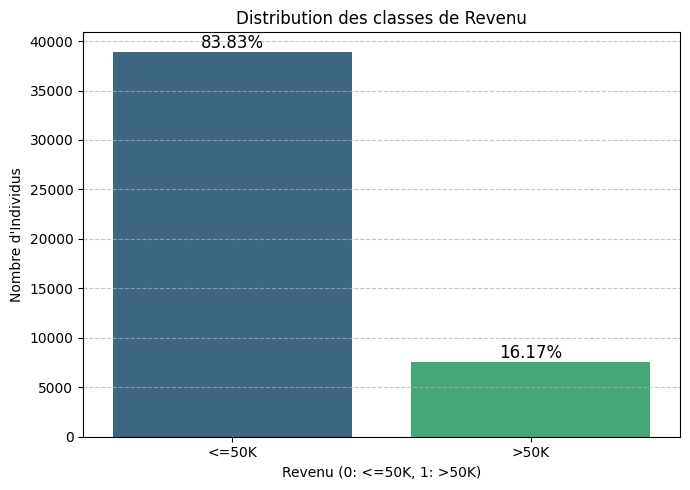

In [ ]:
# 1. Configuration du graphique
plt.figure(figsize=(7, 5))
ax = sns.countplot(x=y_encoded_final, palette='viridis')

# 2. Ajout des pourcentages sur les barres (très utile pour l'analyse du déséquilibre)
total = len(y_encoded_final)
for p in ax.patches:
    percentage = '{:.2f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    # Annoter avec le pourcentage
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)

# 3. Configuration des titres et des étiquettes
plt.title('Distribution des classes de Revenu')
plt.xlabel('Revenu (0: <=50K, 1: >50K)')
plt.ylabel("Nombre d'Individus")
plt.xticks([0, 1], ['<=50K', '>50K']) # Nomme clairement les classes
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('distribution_income.png')

# 4. Affichage du graphique
plt.show()

Après visualisation on observe un grand déséquilibre entre ceux dont les revenus sont **$>50\text{K}$** et ceux dont les revenus sont **$\le50\text{K}$**. On peut donc dire que :  
  * La valeur **1** correspondra à la classe minoritaire.
  * La valeur **0** correspondra à la classe majoritaire.

Pour pallier au problème du déséquilibre de classe, nous allons utiliser une **approche hybride** combinant le **suréchantillonnage** de la classe minoritaire et le **sous-échantillonnage** de la classe majoritaire pour atteindre un équilibre souhaité. Cette stratégie fera appel à deux techniques spécifiques :
- **SMOTE** (*Synthetic Minority Over-sampling Technique*), qui va créer des échantillons synthétiques pour la classe minoritaire.
- **ENN** (*Edited Nearest Neighbors*), qui va supprimer les points de la classe majoritaire qui sont trop proches des points de la classe minoritaire, afin de nettoyer la frontière de décision.

### **III - 2 Encodage des variables catégorielles**

Puisque les méthodes d'échantillonnage de la bibliothèque **`imblearn`** nécessitent des données numériques, nous allons d'abord effectuer l'encodage des variables catégorielles restantes : On a opté pour le **One-Hot Encoding (OHE)**

In [ ]:
categorical_cols = X_cleaned.select_dtypes(include=['object']).columns
print("Colonnes catégorielles à encoder :", categorical_cols.tolist())

Colonnes catégorielles à encoder : ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [ ]:
# Application du One-Hot Encoding aux colonnes catégorielles
X_encoded = pd.get_dummies(X_cleaned, columns=categorical_cols, drop_first=True)

# Affichage du bilan
print("\n--- Bilan de l'encodage ---")
print(f"Nombre de colonnes AVANT encodage : {len(X_cleaned.columns)}")
print(f"Nombre de colonnes APRÈS encodage : {len(X_encoded.columns)}")


--- Bilan de l'encodage ---
Nombre de colonnes AVANT encodage : 14
Nombre de colonnes APRÈS encodage : 97


In [ ]:
X_encoded.head(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,2174,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


### **III - 3 Application de l'Équilibrage Hybride (SMOTEENN)**

Nous allons maintenant appliquer la technique **SMOTEENN** sur les données encodées ($X_{\text{encoded}}$) et la variable cible encodée ($y_{\text{encoded\_final}}$).

In [ ]:
# Affichage de la distribution AVANT échantillonnage
print("\n--- Distribution des classes AVANT SMOTEENN ---")
print(Counter(y_encoded_final))

# Initialisation de SMOTEENN
smote_enn = SMOTEENN(random_state=42)

# Application de la technique sur les données
X_resampled, y_resampled = smote_enn.fit_resample(X_encoded, y_encoded_final)

# Affichage de la distribution APRÈS échantillonnage
print("\n--- Distribution des classes APRÈS SMOTEENN ---")
print(Counter(y_resampled))


--- Distribution des classes AVANT SMOTEENN ---
Counter({0: 38935, 1: 7508})

--- Distribution des classes APRÈS SMOTEENN ---
Counter({1: 22935, 0: 17714})


#### **Interprétation de l'Équilibrage (SMOTEENN)**

L'application de la technique hybride **SMOTEENN** a permis de réduire significativement le déséquilibre des classes. **Avant** l'échantillonnage, la classe majoritaire (0, revenu $\le50\text{K}$) comptait $38\ 935$ individus, contre seulement $7\ 508$ pour la classe minoritaire (1, revenu $>50\text{K}$). **Après** SMOTEENN, le jeu de données est beaucoup plus équilibré, avec $22\ 935$ échantillons dans la classe 1 et $17\ 714$ échantillons dans la classe 0. Cette nouvelle distribution, composée d'échantillons originaux sous-échantillonnés (classe 0) et d'échantillons synthétiques suréchantillonnés (classe 1), est désormais prête pour l'entraînement du modèle KNN.

## **IV- Modélisation : Application de KNN**

Ici, il est question d'appliquer l'algorithme des **K plus proches voisins (KNN)** sur les données prétraitées et équilibrées ($X_{\text{resampled}}$, $y_{\text{resampled}}$). Pour le calcul des distances entre les observations, nous allons opter pour la **distance euclidienne**.

Afin de garantir une évaluation fiable et une optimisation robuste du modèle, nous allons splitter nos données rééquilibrées en trois sous-ensembles :

* **Train** : Un ensemble qui sera utilisé pour l'entraînement du modèle ($X_{\text{train}}$ et $y_{\text{train}}$).
* **Validation** : Un ensemble utilisé pour choisir les hyperparamètres (comme le choix du meilleur $K$). Cela permet d'éviter l'**overfitting** lors de l'optimisation ($X_{\text{val}}$ et $y_{\text{val}}$).
* **Test** : L'ensemble final qui servira à l'évaluation impartiale des performances du modèle choisi, en mesurant sa capacité de généralisation sur des données entièrement nouvelles ($X_{\text{test}}$ et $y_{\text{test}}$).


### **IV - 1 Split des données et Sélection des variables**

#### **Étape 1 : Séparation Train(val inclu dans train)/Test (Split Initial)**

  * **Proportion :** Nous séparons d'abord $80\%$ des données pour l'ensemble d'entraînement et de validation combiné ($X_{\text{train\_val}}$, $y_{\text{train\_val}}$) et $20\%$ pour l'ensemble de test **final** ($X_{\text{test}}$, $y_{\text{test}}$).
  * **Objectif :** Mettre l'ensemble de test de côté pour qu'il soit totalement "vierge".

In [ ]:
# 1. Split initial (80% Train/Validation, 20% Test)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,    # 20% pour le test
    random_state=42,
    stratify=y_resampled # Maintient l'équilibre des classes
)

In [ ]:
# 2. Vérification des dimensions
print("--- Dimensions après Split Initial ---")
print(f"X_train_val (80% Train + Val) : {X_train_val.shape}")
print(f"X_test (20% Test) : {X_test.shape}")

--- Dimensions après Split Initial ---
X_train_val (80% Train + Val) : (32519, 97)
X_test (20% Test) : (8130, 97)


#### **Étape 2 : Standardisation des Caractéristiques**

Nous appliquons la standardisation **uniquement aux variables numériques** (celles qui n'ont pas été transformées par le *One-Hot Encoding*), car ces variables possèdent des échelles variées qui pourraient biaiser le calcul de la distance euclidienne par le KNN.


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# 1. Identification des colonnes numériques
# Dans X_resampled original (avant le split) et donc dans X_train_val,
# les colonnes numériques originales sont :
numerical_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

# 2. Séparation des DataFrames : Numérique et Catégorielle (OHE)
X_train_val_num = X_train_val[numerical_cols]
X_test_num = X_test[numerical_cols]

X_train_val_cat = X_train_val.drop(columns=numerical_cols)
X_test_cat = X_test.drop(columns=numerical_cols)

In [ ]:
# 3. Initialisation et Ajustement (Fit) du StandardScaler sur l'ensemble Train/Validation
scaler = StandardScaler()
scaler.fit(X_train_val_num)

# 4. Transformation des ensembles
X_train_val_num_scaled = scaler.transform(X_train_val_num)
X_test_num_scaled = scaler.transform(X_test_num) # Application des mêmes paramètres au Test

In [ ]:
# 5. Reconstitution des DataFrames standardisés
# Nous convertissons les numpy arrays de retour en DataFrames
X_train_val_num_scaled_df = pd.DataFrame(X_train_val_num_scaled, columns=numerical_cols, index=X_train_val_num.index)
X_test_num_scaled_df = pd.DataFrame(X_test_num_scaled, columns=numerical_cols, index=X_test_num.index)

In [ ]:
# Recombinaison avec les colonnes catégorielles (déjà OHE)
X_train_val_scaled = pd.concat([X_train_val_num_scaled_df, X_train_val_cat], axis=1)
X_test_scaled = pd.concat([X_test_num_scaled_df, X_test_cat], axis=1)

In [ ]:
# 6. Vérification
print("\n--- Bilan de la Standardisation ---")
print(f"Moyenne de la colonne 'age' dans X_train_val_scaled : {X_train_val_scaled['age'].mean():.4f}")
print(f"Écart-type de la colonne 'age' dans X_train_val_scaled : {X_train_val_scaled['age'].std():.4f}")
print(f"Nombre de colonnes total dans X_train_val_scaled : {X_train_val_scaled.shape[1]}")


--- Bilan de la Standardisation ---
Moyenne de la colonne 'age' dans X_train_val_scaled : 0.0000
Écart-type de la colonne 'age' dans X_train_val_scaled : 1.0000
Nombre de colonnes total dans X_train_val_scaled : 97


#### **Étape 3 : Sélection des Variables**

  * **Action :** Sur $X_{\text{train\_val}}$ standardisé, nous appliquons une méthode de sélection de variables : l'**ACP**.
    - Nous allons analyser le nombre de composantes nécessaires pour expliquer une variance cumulée de $\text{80\%}$.
  * **Règle d'Or :** Les paramètres de sélection/réduction sont calculés sur $X_{\text{train\_val}}$ et appliqués à $X_{\text{test}}$.

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
# 1. Ajustement de l'ACP uniquement sur l'ensemble d'entraînement standardisé
pca = PCA()
pca.fit(X_train_val_scaled)

PCA()

In [ ]:
# 2. Analyse de la variance expliquée cumulée
variance_ratio_cumulative = np.cumsum(pca.explained_variance_ratio_)

# 3. Trouvons le nombre de composantes pour expliquer 80% de la variance
n_components_80 = np.where(variance_ratio_cumulative >= 0.80)[0][0] + 1

print("--- Bilan de l'ACP ---")
print(f"Nombre total de caractéristiques (colonnes) : {X_train_val_scaled.shape[1]}")
print(f"Nombre de composantes nécessaires pour expliquer 80% de la variance : {n_components_80}")

--- Bilan de l'ACP ---
Nombre total de caractéristiques (colonnes) : 97
Nombre de composantes nécessaires pour expliquer 80% de la variance : 9


Une fois le nombre optimal de composantes trouvé (ici qui est 9), nous réajustons l'ACP avec ce nombre, puis nous appliquons la transformation aux ensembles d'entraînement et de test.

In [ ]:
# 4. Réinitialisons et ajustons l'ACP avec le nombre optimal de composantes
pca_final = PCA(n_components=n_components_80)
pca_final.fit(X_train_val_scaled)

PCA(n_components=np.int64(9))

In [ ]:
# 5. Transformation des ensembles
X_train_val_pca = pca_final.transform(X_train_val_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

In [ ]:
# 6. Vérification des dimensions
print("\n--- Dimensions après Réduction de Dimensionnalité ---")
print(f"X_train_val_pca (Réduit) : {X_train_val_pca.shape}")
print(f"X_test_pca (Réduit) : {X_test_pca.shape}")


--- Dimensions après Réduction de Dimensionnalité ---
X_train_val_pca (Réduit) : (32519, 9)
X_test_pca (Réduit) : (8130, 9)


**Interprétation :**  
- On peut voir qu'on a réduit le nombre de caractéristiques de **97** à **9 composantes principales**, tout en conservant **$80\%$ de la variance informative** des données. Ce gain d'efficacité est significatif pour le modèle KNN.

#### **Étape 4 : Séparation Train/Validation (Split Final)**

  * **Proportion :** L'ensemble $X_{\text{train\_val}}$ (qui représente maintenant $80\%$ des données) est divisé en deux parties égales.
  * **Résultat :**
      * **$\text{60\%}$ (Train)** : $X_{\text{train}}$ et $y_{\text{train}}$ (utilisés pour entraîner le modèle).
      * **$\text{20\%}$ (Validation)** : $X_{\text{val}}$ et $y_{\text{val}}$ (utilisés pour trouver le meilleur hyperparamètre $K$).

In [ ]:
# Nous utilisons test_size=0.25 car 25% de X_train_val (80%) donne 20% du total.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val_pca,
    y_train_val,
    test_size=0.25,    # 25% de 80% = 20%
    random_state=42,
    stratify=y_train_val # Maintient l'équilibre des classes
)

In [ ]:
# 2. Vérification des dimensions finales
print("--- Dimensions après Split Final (60/20/20) ---")
print(f"X_train (60%) : {X_train.shape}")
print(f"X_val (20%) : {X_val.shape}")
print(f"X_test (20%) : {X_test_pca.shape}")

--- Dimensions après Split Final (60/20/20) ---
X_train (60%) : (24389, 9)
X_val (20%) : (8130, 9)
X_test (20%) : (8130, 9)


### **IV - 2 Choix des hyperparamètres : Optimisation de K**

L'objectif est de trouver la valeur optimale de **$K$** (le nombre de voisins) qui minimise l'erreur sur l'ensemble de **validation** ($X_{\text{val}}$, $y_{\text{val}}$). Nous testerons une plage de valeurs de $K$ de $K=1$ à $K=30$.


Comme nous avons un problème de classification déséquilibrée (même après SMOTEENN, il reste un déséquilibre résiduel et l'intérêt se porte sur la classe minoritaire), nous devons utiliser des métriques plus robustes que la simple *Accuracy* :

  * **F1-Score** (ou F-mesure, ce qu'on va utiliser ici) : C'est la moyenne harmonique de la précision et du rappel, particulièrement pertinente pour évaluer la performance sur la classe minoritaire.
  * **Rappel (Recall)** : Mesure la capacité du modèle à identifier correctement tous les individus de la classe positive ($>50\text{K}$).

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Plage de valeurs de K à tester
k_values = range(1, 31)
f1_scores = []

# Itération pour trouver le meilleur K
for k in k_values:
    # 1. Entraînement sur l'ensemble d'entraînement
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)

    # 2. Prédiction sur l'ensemble de validation
    y_pred_val = knn.predict(X_val)

    # 3. Évaluation (F1-Score)
    # L'average='binary' est utilisé car c'est un problème binaire
    score = f1_score(y_val, y_pred_val, average='binary')
    f1_scores.append(score)

# Trouvons le meilleur K
best_k_index = f1_scores.index(max(f1_scores))
best_k = k_values[best_k_index]

print("--- Optimisation de K terminée ---")
print(f"Meilleur F1-Score sur Validation : {max(f1_scores):.4f}")
print(f"Valeur optimale de K trouvée : {best_k}")

--- Optimisation de K terminée ---
Meilleur F1-Score sur Validation : 0.8931
Valeur optimale de K trouvée : 3


#### **Interprétation de l'Optimisation de $K$**

L'analyse des performances sur l'ensemble de validation ($X_{\text{val}}$, $y_{\text{val}}$) révèle :

  * **Valeur optimale de $K$** : $K = 3$.
  * **Performance associée** : Un **F1-Score de $0.8931$**.

Une valeur de $K$ aussi petite ($K=3$) indique que les frontières de décision sont probablement assez claires dans l'espace réduit à 9 dimensions par l'ACP. Cette valeur sera utilisée pour entraîner le modèle final avant son évaluation sur l'ensemble de test.

### **IV - 3 Évaluation Finale du Modèle KNN**

L'étape finale de l'étude du modèle KNN consiste à évaluer ses performances sur l'ensemble de **Test** ($X_{\text{test}}$, $y_{\text{test}}$), qui n'a jamais été utilisé ni pour l'entraînement, ni pour l'optimisation.


#### **Entraînement du Modèle Final**

Nous allons entraîner le modèle KNN une dernière fois en utilisant la valeur optimale $K=3$ sur l'ensemble d'entraînement complet ($X_{\text{train}}$, $y_{\text{train}}$).

In [ ]:
# 1. Entraînement du modèle KNN final avec K=3
best_k = 3
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_final.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=3)

In [ ]:
# 2. Prédiction sur l'ensemble de Test (X_test_pca)
y_pred_test = knn_final.predict(X_test_pca)

#### **Évaluation sur l'Ensemble de Test**

Nous allons générer un rapport de classification complet sur les données de test, comprenant ces métriques clés : Précision, Rappel, F1-Score.

In [ ]:
# 3. Affichage du Rapport de Classification
print("--- Rapport de Classification Final (Test Set, K=3) ---")
print(classification_report(y_test, y_pred_test))

--- Rapport de Classification Final (Test Set, K=3) ---
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      3543
           1       0.88      0.92      0.90      4587

    accuracy                           0.88      8130
   macro avg       0.88      0.88      0.88      8130
weighted avg       0.88      0.88      0.88      8130



In [ ]:
# Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred_test)

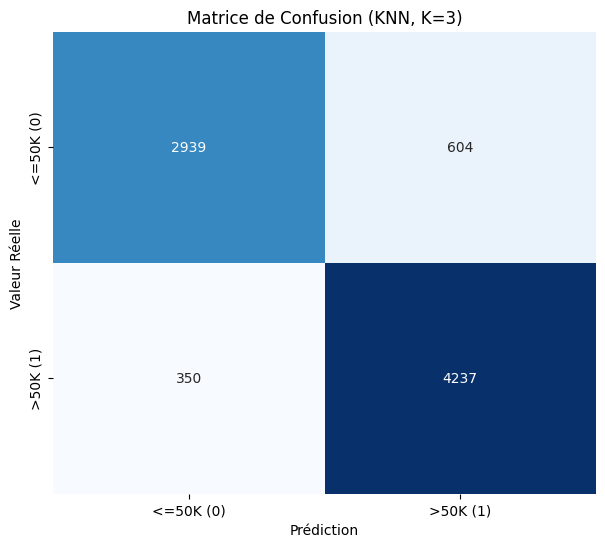

In [ ]:
# Définition des étiquettes des classes
class_labels = ['<=50K (0)', '>50K (1)']

# Configuration du graphique
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,              # Affiche les nombres dans les cellules
    fmt='d',                 # Format des nombres (entiers)
    cmap='Blues',            # Palette de couleurs
    cbar=False,              # Masquer la barre de couleur
    xticklabels=class_labels,
    yticklabels=class_labels
)

# Configuration des titres et des axes
plt.title('Matrice de Confusion (KNN, K=3)')
plt.xlabel('Prédiction')
plt.ylabel('Valeur Réelle')

# Sauvegarde de l'image
plt.savefig('matrice_confusion_knn.png')
plt.show()

## **V - Interprétation de l'Évaluation Finale (KNN)**

L'évaluation du modèle K plus proches voisins (KNN) avec **$K=3$** sur l'ensemble de test démontre une performance **très solide et équilibrée** pour la prédiction du revenu.

### **Synthèse des Performances**

* **Précision globale (*Accuracy*)** : Le modèle a atteint un score de **$88\%$**.
* **F1-Score** : Le score de **$0.90$** pour la classe minoritaire (revenu $>50\text{K}$) est excellent. Ce résultat confirme que la stratégie d'équilibrage par **SMOTEENN** a été très efficace pour gérer le déséquilibre initial.
* **Rappel (*Recall*) pour la Classe $>50\text{K}$** : Avec **$92\%$**, le modèle est particulièrement performant pour identifier correctement les individus ayant un haut revenu, ce qui est souvent l'objectif prioritaire dans ce type d'étude socio-économique.
* **Précision (*Precision*) pour la Classe $>50\text{K}$** : Le modèle a une précision de **$88\%$**, indiquant que lorsqu'il prédit un haut revenu, il se trompe rarement.

### **Analyse de la Matrice de Confusion**

La matrice de confusion montre que le modèle distingue efficacement les individus à haut revenu, avec un rappel élevé (≈ 92 %, soit 4237 correctement identifiés contre seulement 350 manqués), ce qui confirme sa capacité à limiter les erreurs de classification dans cette classe. On observe également une bonne reconnaissance des individus à faible revenu (2939 bien classés, pour 604 erreurs), ce qui traduit un équilibre global entre précision et rappel.

En somme, la matrice confirme que le modèle prédit correctement la majorité des cas et qu’il capture bien la structure des données, avec seulement quelques erreurs résiduelles qui n’affectent pas la tendance générale.

### **Conclusion :**

Le modèle KNN final démontre une **robustesse remarquable**, avec des performances équilibrées sur les deux classes. Ces résultats confirment la pertinence des étapes de prétraitement mises en œuvre de l’équilibrage des données à la standardisation, en passant par la réduction de dimension par ACP - et valident la cohérence de l’ensemble du pipeline.



# **Partie 2 : Grandient Boosting sur les Données Relationnelles Cora**

## **I - Préparation des Données de Cora**


### **I - 1 Chargement et Nettoyage de Cora**

L'objectif est de charger les matrices des caractéristiques ($X$), des liens ($W$), et les labels de classe ($gnd$) depuis le fichier `cora.mat`. Ce type de fichier (MATLAB `.mat`) nécessite l'utilisation de la bibliothèque `scipy.io` pour l'ouvrir, et la plupart des données sont stockées au format de matrice creuse (*sparse*).

Nous allons extraire les données et les variables nommées pour l'étude de Cora.




In [ ]:
import scipy.sparse as sp
import joblib
import os

from scipy.io import loadmat

In [ ]:
def load_relation_data(file_path):
    """
    Charge les matrices de caractéristiques (X), d'adjacence (W) et les labels (gnd)
    à partir d'un fichier .mat (Cora, CiteSeer, ou Pubmed).
    """
    try:
        # 1. Chargement des données à partir du fichier .mat
        data = loadmat(file_path)
    except FileNotFoundError:
        print(f"Erreur : Le fichier {file_path} est introuvable.")
        return None, None, None # Retourne None en cas d'erreur

    # 2. Extraction et standardisation des matrices
    # Les clés dépendent du format de la base, nous assumons 'fea' pour X, 'W' pour W, 'gnd' pour gnd

    # --- Matrice des caractéristiques (X) ---
    X = data['fea']

    # Conversion de X en format dense (ndarray) si elle est sparse.
    # Ceci est nécessaire pour les calculs matriciels comme la création de M = D^(-1) * W * X
    if sp.issparse(X):
        X = X.A

    # --- Matrice des liens (W) ---
    W = data['W']

    # --- Vecteur des labels (gnd) ---
    gnd = data['gnd']
    # gnd est souvent une colonne, nous le transformons en vecteur 1D
    gnd = gnd.flatten()

    # print(f"Chargement de {file_path} terminé.")
    # print(f"Dimensions de X : {X.shape}")
    # print(f"Dimensions de W : {W.shape}")
    # print(f"Dimensions de gnd : {gnd.shape}")

    return X, W, gnd

In [ ]:
FILE_PATH_CORA = "/content/drive/MyDrive/data_App_sup/cora.mat"
X_cora, W_cora, gnd_cora = load_relation_data(FILE_PATH_CORA)

In [ ]:
# Vérification des dimensions
print("Chargement et préparation des matrices de Cora terminés.")
print(f"Dimensions de X_cora (Caractéristiques) : {X_cora.shape}")
print(f"Dimensions de W_cora (Liens) : {W_cora.shape}")
print(f"Dimensions de gnd_cora (Labels) : {gnd_cora.shape}")

Chargement et préparation des matrices de Cora terminés.
Dimensions de X_cora (Caractéristiques) : (2708, 1433)
Dimensions de W_cora (Liens) : (2708, 2708)
Dimensions de gnd_cora (Labels) : (2708,)


In [ ]:
gnd_series = pd.Series(gnd_cora)
counts = gnd_series.value_counts().sort_index()

In [ ]:
counts

,count
1,351
2,217
3,418
4,818
5,426
6,298
7,180


### **I - 2 Création de la Matrice Enrichie ($M_{\text{cora}}$)**

Il est question ici, de calculer la matrice enrichie $M_{\text{cora}}$, qui combine les caractéristiques ($X_{\text{cora}}$) avec l'information structurelle du réseau de citations ($W_{\text{cora}}$).

La matrice $M_{\text{cora}}$ est définie par la formule :
$$M = D^{\wedge}(-1) \cdot W \cdot X$$
Où :

  * **$X_{\text{cora}}$** est la matrice des caractéristiques.
  * **$W_{\text{cora}}$** est la matrice d'adjacence des liens (matrice creuse *sparse*).
  * **$D^{\wedge}(-1)$** est l'inverse de la matrice diagonale des degrés ($D$), où chaque élément sur la diagonale est la somme des liens d'un nœud (ligne) dans $W_{\text{cora}}$.



In [ ]:
# 1. Conversion de W_cora en format CSR pour les opérations

if isinstance(W_cora, np.ndarray):
    # Cas 1: Si c'est une matrice dense (ndarray), on la convertit en CSR sparse
    W_cora_csr = sp.csr_matrix(W_cora)
else:
    # Cas 2: Si c'est déjà un objet sparse (coo, csc, etc.), on le convertit en CSR
    W_cora_csr = W_cora.tocsr()

In [ ]:
 W_cora_csr

<Compressed Sparse Row sparse matrix of dtype 'uint8'
	with 10556 stored elements and shape (2708, 2708)>

In [ ]:
# 2. Calcul de la matrice D (Matrice diagonale des degrés)
# degrees est la somme des éléments de chaque ligne de W_cora_csr
degrees = W_cora_csr.sum(axis=1).A1

In [ ]:
degrees

array([3, 3, 5, ..., 1, 4, 4], dtype=uint64)

In [ ]:
# 3. Création de D^(-1)
# Gestion des degrés nuls : Si un nœud n'a aucun lien, son degré est 0.
# Nous remplaçons 0 par 1 pour éviter la division par zéro dans l'inverse.
degrees[degrees == 0] = 1
D_inv = sp.diags(1.0 / degrees)

In [ ]:
D_inv

<DIAgonal sparse matrix of dtype 'float64'
	with 2708 stored elements (1 diagonals) and shape (2708, 2708)>

In [ ]:
# 4. Calcul de la Matrice Enrichie M_cora = D^(-1) * W * X
# Puisque W_cora est sparse, nous utilisons les opérations de multiplication sparse
# X_cora doit être traité pour garantir qu'il s'agit bien d'une matrice dense 2D (ndarray)
if sp.issparse(X_cora):
    X_cora_dense = X_cora.A
else:
    X_cora_dense = X_cora

M_cora = D_inv.dot(W_cora_csr).dot(X_cora_dense)
print("Création de la matrice enrichie M_cora terminée.")
print(f"Dimensions de M_cora (Matrice Enrichie) : {M_cora.shape}")

Création de la matrice enrichie M_cora terminée.
Dimensions de M_cora (Matrice Enrichie) : (2708, 1433)


In [ ]:
M_cora[:5]

array([[0.        , 0.        , 0.        , ..., 0.        , 0.33333333,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.2       , 0.        , ..., 0.        , 0.        ,
        0.        ]])

### **I - 3 Split Initial Train/Test**

On va séparer les données en
- Ensemble d'entraînement ($80\%$)
- Ensemble de test ($20\%$) pour l'évaluation finale.

Nous allons utiliser la **stratification** sur les labels $gnd_{\text{cora}}$ pour garantir que les proportions des **7 classes** sont conservées dans les deux ensembles.


In [ ]:
# 1. Split initial (80% Train, 20% Test)

# Split pour X (Caractéristiques seules) et gnd
X_cora_train, X_cora_test, gnd_cora_train, gnd_cora_test = train_test_split(
    X_cora,
    gnd_cora,
    test_size=0.2,    # 20% pour le test
    random_state=42,
    stratify=gnd_cora # Maintient la proportion des 7 classes
)

# Split pour M (Caractéristiques enrichies) - Nous utilisons le même random_state et stratify
# L'ordre des données dans X et M doit être identique, ce qui est assuré par l'ordre des matrices d'entrée.
M_cora_train, M_cora_test, _, _ = train_test_split(
    M_cora,
    gnd_cora,
    test_size=0.2,
    random_state=42,
    stratify=gnd_cora
)

# 2. Vérification des dimensions
print("--- Dimensions après Split Initial (Cora) ---")
print(f"X_cora_train (80%) : {X_cora_train.shape}")
print(f"M_cora_train (80%) : {M_cora_train.shape}")
print(f"gnd_cora_train (80%) : {gnd_cora_train.shape}")
print(f"X_cora_test (20%) : {X_cora_test.shape}")
print(f"M_cora_test (20%) : {M_cora_test.shape}")
print(f"gnd_cora_test (20%) : {gnd_cora_test.shape}")

--- Dimensions après Split Initial (Cora) ---
X_cora_train (80%) : (2166, 1433)
M_cora_train (80%) : (2166, 1433)
gnd_cora_train (80%) : (2166,)
X_cora_test (20%) : (542, 1433)
M_cora_test (20%) : (542, 1433)
gnd_cora_test (20%) : (542,)


## **II - Modélisation**

Elle va se faire en plusieurs étapes :

* **Standardisation**
* **Optimisation des Hyperparamètres :** en utilisant la **Validation Croisée** pour déterminer les meilleurs hyperparamètres pour le Gradient Boosting (*learning rate*, *max depth*, etc.) sur l'ensemble d'entraînement.
* **Entraînement :** qui va consister à entraîner le modèle Gradient Boosting final.
* **Évaluation** : qui va consister à évaluer les performances sur l'ensemble de test ($X_{\text{test}}$ ou $M_{\text{test}}$) à l'aide de métriques comme l'**Accuracy** et le **F1-Score**.

### **II - 1 Standardisation des Caractéristiques**

Nous passons à la **standardisation** (mise à l'échelle) : Cette étape est cruciale pour que le modèle n'accorde pas un poids disproportionné aux caractéristiques qui ont une variance plus élevée.


In [ ]:
# 1. SCÉNARIO X : Standardisation de X_cora (Caractéristiques seules)
scaler_X = StandardScaler()
X_cora_train_scaled = scaler_X.fit_transform(X_cora_train)
X_cora_test_scaled = scaler_X.transform(X_cora_test)

# 2. SCÉNARIO M : Standardisation de M_cora (Caractéristiques enrichies)
scaler_M = StandardScaler()
M_cora_train_scaled = scaler_M.fit_transform(M_cora_train)
M_cora_test_scaled = scaler_M.transform(M_cora_test)

# 3. Vérification (ex. : première colonne du train set de X)
print("--- Bilan de la Standardisation ---")
print(f"Moyenne de la première colonne de X_cora_train_scaled : {X_cora_train_scaled[:, 0].mean():.4f}")
print(f"Écart-type de la première colonne de X_cora_train_scaled : {X_cora_train_scaled[:, 0].std():.4f}")

print("\n Les ensembles X et M sont standardisés et prêts pour la modélisation.")

--- Bilan de la Standardisation ---
Moyenne de la première colonne de X_cora_train_scaled : -0.0000
Écart-type de la première colonne de X_cora_train_scaled : 1.0000

 Les ensembles X et M sont standardisés et prêts pour la modélisation.


### **II - 2 Optimisation des Hyperparamètres : Validation Croisée**

Puisque le **Gradient Boosting (GBM)** est un modèle puissant, l'optimisation des hyperparamètres est essentielle. Nous allons utiliser la **Validation Croisée (CV)** sur l'ensemble d'entraînement pour trouver la combinaison optimale du **Taux d'Apprentissage (learning rate)** et de la **Profondeur Maximale de l'Arbre (max_depth)**.

Valeurs de test :
- **Learning rate** : 0.03, 0.05, 0.10, 0.20.
- **Profondeur maximale** : 3, 5, 7, 10.
- **CV** : 3 fold.
- Nous utilisons l'accuracy comme métrique, car le problème est multi-classes (7 classes).

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, make_scorer

#### **II - 2 - 1 Optimisation : Scénario X**

In [ ]:
# 1. Définition de la grille de recherche
# Nous testons différentes combinaisons d'hyperparamètres
param_grid = {
    'learning_rate': [0.03, 0.05, 0.10, 0.20],
    'max_depth': [3, 5, 7, 10],
    'n_estimators': [100] # On fixe le nombre d'estimateurs pour ce premier test
}

In [ ]:
# 2. Initialisation du modèle GBM
gbm = GradientBoostingClassifier(random_state=42)
gbm

GradientBoostingClassifier(random_state=42)

In [ ]:
# 3. Initialisation de GridSearchCV avec Validation Croisée (CV=3)
# Nous utilisons l'accuracy comme métrique, car le problème est multi-classes (7 classes)
# et nous n'avons pas de déséquilibre extrême ici.
grid_search_X = GridSearchCV(
    estimator=gbm,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,              # 3-fold Cross-Validation
    verbose=1,
    n_jobs=-1          # Utilisation de tous les cœurs disponibles
)

In [ ]:
# 4. Ajustement (Fit) : Lancement de la recherche sur les données d'entraînement standardisées
print("Lancement de la recherche d'hyperparamètres pour le Scénario X (X_cora)...")
grid_search_X.fit(X_cora_train_scaled, gnd_cora_train)

Lancement de la recherche d'hyperparamètres pour le Scénario X (X_cora)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.03, 0.05, 0.1, 0.2],
                         'max_depth': [3, 5, 7, 10], 'n_estimators': [100]},
             scoring='accuracy', verbose=1)

In [ ]:
# Définition du chemin de sauvegarde
file_name_X = '/content/drive/MyDrive/data_App_sup/grid_search_cora_X.joblib'

# . Sauvegarde de l'objet entraîné
joblib.dump(grid_search_X, file_name_X)

print(f"\n Résultats de Grid Search sauvegardés sous : {file_name_X}")


 Résultats de Grid Search sauvegardés sous : /content/drive/MyDrive/data_App_sup/grid_search_cora_X.joblib


In [ ]:
# 5. Affichage des meilleurs résultats
print("\n--- Meilleurs Hyperparamètres (Scénario X) ---")
print(f"Meilleure Accuracy CV : {grid_search_X.best_score_:.4f}")
print(f"Meilleurs paramètres : {grid_search_X.best_params_}")


--- Meilleurs Hyperparamètres (Scénario X) ---
Meilleure Accuracy CV : 0.7331
Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


**Bilan de l'Optimisation : Scénario X**

Les résultats de la **Validation Croisée** sur l'ensemble d'entraînement pour le Gradient Boosting, utilisant les caractéristiques seules ($X_{\text{cora}}$), sont les suivants :

  * **Meilleure Accuracy CV** : **$0.7331$** (soit $73.31\%$ de classification correcte).
  * **Meilleurs paramètres** :
      * `learning_rate` (Taux d'apprentissage) : **$0.1$**
      * `max_depth` (Profondeur maximale des arbres) : **$3$**
      * `n_estimators` (Nombre d'arbres) : **$100$**

L'accuracy de $73.31\%$ est un bon point de référence. Maintenant, nous allons voir si l'ajout de l'information du graphe ($M$) peut améliorer ce score.


#### **II - 2 - 2 Optimisation : Scénario M**

Ici il s'agit de répéter l'étape d'optimisation par **Validation Croisée** pour le **Scénario M** (Caractéristiques enrichies).

L'objectif est de trouver les meilleurs hyperparamètres pour le Gradient Boosting lorsqu'il utilise la matrice enrichie $M_{\text{cora\_train\_scaled}}$ et de comparer la meilleure *Accuracy CV* avec celle du Scénario X ($0.7331$).

In [ ]:
# 1. Initialisation du modèle GBM
gbm = GradientBoostingClassifier(random_state=42)

In [ ]:
# 2. Initialisation de GridSearchCV avec Validation Croisée
grid_search_M = GridSearchCV(
    estimator=gbm,
    param_grid=param_grid,
    scoring='accuracy', # Métrique standard pour la classification multi-classes
    cv=3,              # 3-fold Cross-Validation
    verbose=1,
    n_jobs=-1          # Utilisation de tous les cœurs disponibles
)

In [ ]:
# 3. Ajustement (Fit) : Lancement de la recherche sur les données M_cora standardisées

print("Lancement de la recherche d'hyperparamètres pour le Scénario M (M_cora enrichi)...")
grid_search_M.fit(M_cora_train_scaled, gnd_cora_train)

Lancement de la recherche d'hyperparamètres pour le Scénario M (M_cora enrichi)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.03, 0.05, 0.1, 0.2],
                         'max_depth': [3, 5, 7, 10], 'n_estimators': [100]},
             scoring='accuracy', verbose=1)

In [ ]:
# Définition du chemin de sauvegarde
file_name_M = '/content/drive/MyDrive/data_App_sup/grid_search_cora_M.joblib'

# . Sauvegarde de l'objet entraîné
joblib.dump(grid_search_M, file_name_M)

print(f"\n Résultats de Grid Search sauvegardés sous : {file_name_M}")


 Résultats de Grid Search sauvegardés sous : /content/drive/MyDrive/data_App_sup/grid_search_cora_M.joblib


In [ ]:
# 4. Affichage des meilleurs résultats
print("\n--- Meilleurs Hyperparamètres (Scénario M) ---")
print(f"Meilleure Accuracy CV : {grid_search_M.best_score_:.4f}")
print(f"Meilleurs paramètres : {grid_search_M.best_params_}")


--- Meilleurs Hyperparamètres (Scénario M) ---
Meilleure Accuracy CV : 0.7955
Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


#### **Comparaison des Meilleurs Hyperparamètres**

| Scénario | Données | Meilleure Accuracy CV | Meilleurs Paramètres |
| :--- | :--- | :--- | :--- |
| **X (Caractéristiques seules)** | $X_{\text{cora}}$ | $0.7331$ | lr: 0.1, max_depth: 3, n_estimators: 100 |
| **M (Caractéristiques enrichies)** | $M_{\text{cora}}$ | **$0.7955$** | lr: 0.1, max_depth: 3, n_estimators: 100 |


#### **Observation**

L'ajout de l'information structurelle du graphe via la matrice $M_{\text{cora}}$ a permis au modèle Gradient Boosting d'obtenir une amélioration de performance significative de **$6.24$ points de pourcentage** ($0.7955 - 0.7331$). Les hyperparamètres optimaux restent stables entre les deux scénarios.

### **III Évaluation Finale sur l'Ensemble de Test**

Ici il s'agit d'évaluer les modèles finaux sur l'ensemble de **Test** ($X_{\text{cora\_test}}$, $M_{\text{cora\_test}}$, $gnd_{\text{cora\_test}}$) pour obtenir une estimation impartiale de leur performance réelle.




#### **III - 1 Entraînement et Évaluation**

Nous allons entraîner un modèle final pour chaque scénario en utilisant les paramètres optimaux trouvés (qui sont les mêmes pour les deux) et évaluer l'Accuracy et le F1-Score sur l'ensemble de test, car l'entraînement initial dans la Validation Croisée (GridSearchCV) n'a jamais exposé le modèle à $100\%$ des données d'entraînement. En réentraînant le modèle sur la totalité de l'ensemble d'entraînement ($80\%$) avec les meilleurs hyperparamètres, nous maximisons sa capacité à apprendre les relations complexes et garantissons le modèle le plus performant possible avant l'évaluation finale impartiale sur l'ensemble de test.

In [ ]:
# Hyperparamètres optimaux (identiques pour X et M)
OPTIMAL_PARAMS = {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

In [ ]:
# --- SCÉNARIO X : Caractéristiques seules ---
# 1. Entraînement du modèle final X
gbm_X = GradientBoostingClassifier(**OPTIMAL_PARAMS, random_state=42)
gbm_X.fit(X_cora_train_scaled, gnd_cora_train)


GradientBoostingClassifier(random_state=42)

In [ ]:
# 2. Prédiction et Évaluation sur le Test Set
gnd_pred_X = gbm_X.predict(X_cora_test_scaled)
acc_X = accuracy_score(gnd_cora_test, gnd_pred_X)
f1_X = f1_score(gnd_cora_test, gnd_pred_X, average='macro') # Multi-classes

In [ ]:
# --- SCÉNARIO M : Caractéristiques enrichies ---
# 1. Entraînement du modèle final M
gbm_M = GradientBoostingClassifier(**OPTIMAL_PARAMS, random_state=42)
gbm_M.fit(M_cora_train_scaled, gnd_cora_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
# 2. Prédiction et Évaluation sur le Test Set
gnd_pred_M = gbm_M.predict(M_cora_test_scaled)
acc_M = accuracy_score(gnd_cora_test, gnd_pred_M)
f1_M = f1_score(gnd_cora_test, gnd_pred_M, average='macro')

In [ ]:
# 3. Affichage des résultats
print("--- Évaluation Finale sur l'Ensemble de Test (Cora) ---")
print(f"Scénario X (Seul) : Accuracy = {acc_X:.4f}, F1-Score (Macro) = {f1_X:.4f}")
print(f"Scénario M (Enrichi) : Accuracy = {acc_M:.4f}, F1-Score (Macro) = {f1_M:.4f}")

--- Évaluation Finale sur l'Ensemble de Test (Cora) ---
Scénario X (Seul) : Accuracy = 0.7343, F1-Score (Macro) = 0.7214
Scénario M (Enrichi) : Accuracy = 0.8044, F1-Score (Macro) = 0.7899


#### **Courbe ROC**

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


In [ ]:
gnd_cora_test[:5]

array([3, 4, 4, 4, 3], dtype=uint8)

In [ ]:
# Binarisation des labels pour le calcul One-vs-Rest (OvR)
y_test_binarized = label_binarize(gnd_cora_test, classes=np.unique(gnd_cora_test))

# Prédictions des Probabilités sur le Test Set
y_proba_X = gbm_X.predict_proba(X_cora_test_scaled)
y_proba_M = gbm_M.predict_proba(M_cora_test_scaled)

In [ ]:
# --- 2. Fonction de Calcul ROC OvR (Macro-moyenne) ---
def calculate_ovr_roc(y_true_bin, y_proba):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Calcul de la moyenne Macro (interpolation des courbes)
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    return fpr, tpr, roc_auc


In [ ]:
y_test_binarized.shape[1]

7

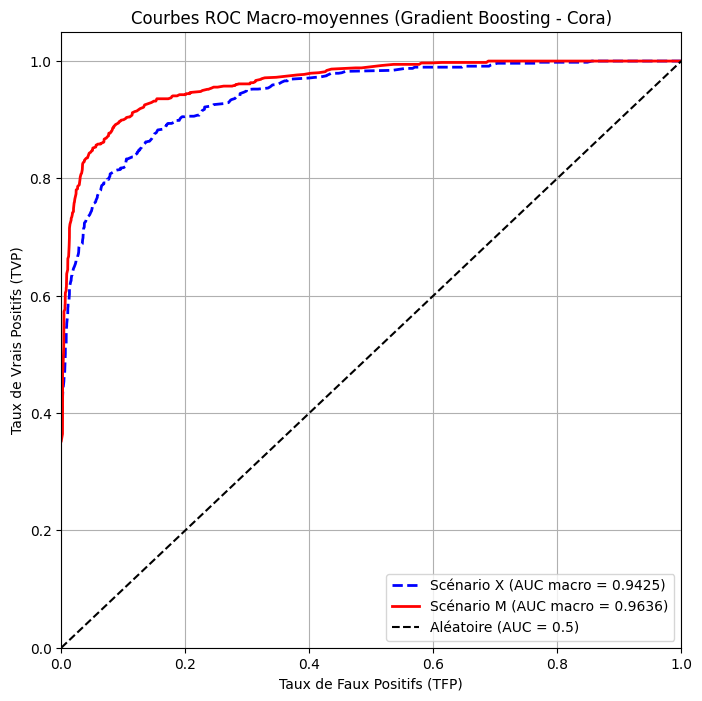

In [ ]:
# Définition du nombre de classes (nécessaire pour la fonction calculate_ovr_roc)
n_classes = y_test_binarized.shape[1]

fpr_X, tpr_X, roc_auc_X = calculate_ovr_roc(y_test_binarized, y_proba_X)
fpr_M, tpr_M, roc_auc_M = calculate_ovr_roc(y_test_binarized, y_proba_M)

# --- 3. Tracé des courbes ROC (Macro-moyenne) ---
plt.figure(figsize=(8, 8))

# Courbe X (Seul)
plt.plot(
    fpr_X["macro"],
    tpr_X["macro"],
    label=f'Scénario X (AUC macro = {roc_auc_X["macro"]:.4f})',
    color='blue',
    linewidth=2,
    linestyle='--'
)

# Courbe M (Enrichi)
plt.plot(
    fpr_M["macro"],
    tpr_M["macro"],
    label=f'Scénario M (AUC macro = {roc_auc_M["macro"]:.4f})',
    color='red',
    linewidth=2
)

# Configuration du graphique
plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (TFP)')
plt.ylabel('Taux de Vrais Positifs (TVP)')
plt.title('Courbes ROC Macro-moyennes (Gradient Boosting - Cora)')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig('/content/drive/MyDrive/data_App_sup/courbe_roc_cora.png')
plt.show()

In [ ]:
print(f"AUC Macro (Scénario X): {roc_auc_X['macro']:.4f}")
print(f"AUC Macro (Scénario M): {roc_auc_M['macro']:.4f}")

AUC Macro (Scénario X): 0.9425
AUC Macro (Scénario M): 0.9636


### **Interprétation des Résultats Finaux (Cora)**

L'évaluation finale du modèle **Gradient Boosting** sur l'ensemble de test de Cora révèle un impact **positif et significatif** de l'intégration de l'information du graphe :


* **Scénario X (Caractéristiques seules)** : L'*Accuracy* est de **$73.43\%$** et le F1-Score (Macro) est de **$72.14\%$**. Son **AUC Macro est de $0.9425$**. C'est une performance de référence solide pour la classification des publications sans tenir compte des liens de citation.
* **Scénario M (Caractéristiques enrichies)** : L'Accuracy monte à **$80.44\%$** et le F1-Score (Macro) atteint **$78.99\%$**, ainsi que l'**AUC Macro** qui s'élève à **$0.9636$**.


## **IV - Conclusion**


L'utilisation de la matrice enrichie **$M$** a entraîné une amélioration de la performance d'environ **7 points de pourcentage** pour l'*Accuracy* et près de **7 points de pourcentage** pour le F1-Score par rapport à l'utilisation de $X$ seul. L'augmentation de l'AUC Macro démontre que l'information structurelle fournie par le réseau de citations ($W$) est cruciale, elle vient confirmer **l'hypothèse centrale du projet** : l'information structurelle fournie par le réseau de citations ($W$) est **hautement pertinente** pour la tâche de classification des publications scientifiques. En moyennant les caractéristiques des voisins directs (via $D^{\wedge}(-1) \cdot W \cdot X$), la matrice $M$ a permis au modèle Gradient Boosting de prédire la catégorie d'une publication avec une **bien meilleure précision**.